# Residual / Offset-Correction Policy Training

Trains a model that looks at the three camera images and predicts the
6-DoF offset between the SFP/SC connector tip and the target port
(`dx, dy, dz` in meters, `droll, dpitch, dyaw` in degrees, all expressed
in the port's own frame), using the dataset produced by
`aic_solution_policy/data_acquisition.py`.

Two models are trained on the same data:
1. **CNN + MLP regressor** — shared ResNet18 encoder over the 3 views, MLP
   head, plain MSE regression.
2. **Diffusion policy** — a conditional DDPM that denoises a random 6-DoF
   vector into the offset prediction, conditioned on the same image
   features. Useful when the offset distribution is multi-modal (e.g. the
   controller settling against a physical stop can produce non-Gaussian
   residuals) — regression averages modes away, diffusion does not.

The **target label** is computed from the *actual* (ground-truth-TF /
controller-measured) `tip_pose` and `port_pose` stored per sample, not the
commanded `offset` field — the whole reason `data_acquisition.py` records
actual poses is that impedance control may not land exactly on the
commanded pose. `offset` is kept in the dataset only for reference/debugging.


## 0. Environment setup (run in a terminal, *before* launching Jupyter)

This notebook uses a plain Python venv, independent of the ROS/pixi
workspace used by `data_acquisition.py` — the dataset (`.hdf5` files) is
the only thing the two share.

```bash
cd ~/ws_aic/src/aic/aic_solution/aic_solution_policy
python3 -m venv .venv
source .venv/bin/activate
pip install --upgrade pip

# CPU-only PyTorch (simplest, works everywhere):
pip install torch torchvision

# --- OR, for an NVIDIA GPU box, pick the matching CUDA build instead, e.g.:
# pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

pip install h5py numpy opencv-python-headless matplotlib tqdm tensorboard jupyter ipykernel scipy

python -m ipykernel install --user --name aic-residual-policy --display-name "aic-residual-policy"
```

Then open this notebook and select the **aic-residual-policy** kernel
(VSCode: top-right kernel picker; classic Jupyter: Kernel -> Change kernel).

To watch training live, in another terminal (same venv):
```bash
source ~/ws_aic/src/aic/aic_solution/aic_solution_policy/.venv/bin/activate
tensorboard --logdir ~/ws_aic/src/aic/aic_solution/dataset/runs --port 6006
```


In [41]:
import os
import glob
import math
import random
from datetime import datetime

import numpy as np
import cv2
import h5py
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from scipy.spatial.transform import Rotation as Rot

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torch.utils.tensorboard import SummaryWriter

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cuda


In [42]:
# --------------------------------------------------------------------------
# Config -- tweak here, nothing else in the notebook should need editing to
# do a first run once you have data under CFG["data_glob"].
# --------------------------------------------------------------------------
CFG = {
    # Shared with data_acquisition.py's default output_dir and QualificationPlugIn.py's / Phase1PlugIn.py's
    # residual_model_path -- everything training-related lives under
    # src/aic/aic_solution/dataset/ so the ROS pixi env and this venv agree
    # on where to find/put things.
    "data_glob": "/home/intrinsic/ws_aic/src/aic/aic_solution/dataset/hdf5/*.hdf5",
    "cams": ["left", "center", "right"],

    # Which model(s) to train + evaluate this run -- any subset of
    # {"regressor", "diffusion"}. A model not listed here is not trained
    # (section 3/4 print a skip note instead) and not evaluated (section
    # 3.1/4.1 likewise); sections 5/6 (comparison) adapt automatically to
    # however many models actually ran -- 0, 1, or 2.
    "models_to_run": ["regressor", "diffusion"],
    

    # Fixed per-camera ROI crop, applied to the raw image *before* resizing
    # to image_size -- (x0, y0, x1, y1) in raw pixel coordinates, or None to
    # use the full frame uncropped. Keyed by cable_type first (each sample's
    # HDF5 group has a "cable_type" attr set by data_acquisition.py, e.g.
    # "sfp" or "sc") since different connectors sit in different parts of
    # the frame -- one ROI wouldn't fit both. Use the crop-preview cell in
    # section 1.1 to pick these values by eye, per cable type.
    "crop": {
        "sfp": {
            "left": (560, 600, 740, 760),
            "center": (480, 560, 660, 720),
            "right": (420, 600, 600, 760),
        },
        "sc": {
            "left": (570, 660, 710, 800),
            "center": (500, 660, 640, 800),
            "right": (430, 660, 570, 800),
        },
    },
    "image_size": 128,          # resized to (image_size, image_size) before the CNN

    # Train-time-only image augmentation, re-sampled fresh every time a
    # training sample is loaded -- the practical way to multiply the
    # effective size of the training set without collecting more rollouts.
    # Never applied to the val set, so evaluation numbers stay a fair
    # estimate on the un-augmented fixed crop. Preview it in section 1.2.
    "augment": {
        "enabled": True,
        "rotation_deg": 7.5,   # random rotation in [-rotation_deg, +rotation_deg], about the crop box center
        "crop_jitter_px": 10,   # random +/-crop_jitter_px shift of each CFG["crop"] box edge, independently
    },

    # Drop samples whose *true* (actual, not commanded) xy offset exceeds
    # this -- outlier/failed-settle rollouts where the tip landed far off
    # the port shouldn't pull a residual policy's small-offset predictions
    # off center. Set to None to disable. Applied once, before the
    # train/val split, so both splits reflect the same cleaned distribution.
    "filter": {
        # e.g. ["sc"] to train/evaluate only on SC-plug data, ["sfp"] for
        # only SFP, or None to use every cable_type present in the data.
        "cable_types": ["sfp"],
        "max_xy_offset_m": 0.0075,
    },
    "val_fraction": 0.15,
    "split_mode": "random",     # "random" or "by_port" (leave-N-ports-out, see build_index_split)
    "seed": 42,

    # Oversample small-error training samples: a residual policy needs to be
    # most precise exactly when it's already close to aligned, but a uniform
    # training distribution gives it no more practice there than anywhere
    # else. Samples whose *true* position-offset magnitude is below
    # threshold_mm get drawn weight_multiplier times as often per epoch (with
    # replacement) via a WeightedRandomSampler -- see section 2, applies to
    # both the regressor and diffusion training loops since they share
    # train_loader. weight_multiplier=1.0 disables this (uniform sampling).
    "small_error_oversample": {
        "threshold_mm": 2.0,
        "weight_multiplier": 3.0,
    },

    "batch_size": 16,
    "num_workers": 4,
    "lr": 1e-3,
    "weight_decay": 1e-4,

    # Both training loops stop early once val loss hasn't improved for
    # `early_stop_patience`/`diff_early_stop_patience` epochs respectively,
    # so these are just upper bounds.
    "reg_epochs": 200,
    "reg_feat_dim": 256,
    "reg_hidden": 256,

    "diff_epochs": 400,
    "diff_feat_dim": 256,
    "diff_hidden": 256,
    "diff_time_dim": 64,
    "num_diffusion_steps": 100,
    # Linear beta schedule for the DDPM forward process. beta_end is 10x
    # the original Ho et al. (2020) value (0.02) because that value was
    # tuned for 1000 steps -- with only num_diffusion_steps=100 steps it
    # leaves ~60% of the original signal in x_T (alphas_cumprod[-1]~=0.36),
    # so sampling from pure N(0,1) noise starts from a distribution the
    # model never saw during training. 0.2 pushes alphas_cumprod[-1] to
    # ~2e-5, i.e. x_T is effectively pure noise. See section 4's note.
    "diff_beta_start": 1e-4,
    "diff_beta_end": 0.2,
    "diff_eval_samples": 16,    # samples drawn per validation input when evaluating the diffusion model
    "diff_mae_log_every": 5,    # log per-dim val MAE to TensorBoard every N epochs (needs a full
                                 # reverse-diffusion sampling pass, so it's not done every epoch)

    "early_stop_patience": 30,       # regressor: stop if val loss hasn't improved for this many epochs
    "diff_early_stop_patience": 399,  # diffusion: separate patience -- diffusion's val loss (denoising
                                      # MSE on random noise targets) is noisier epoch-to-epoch than the
                                      # regressor's, so it may need a different patience to avoid
                                      # stopping on noise or, conversely, wasting epochs after it's
                                      # actually plateaued.

    # Freeze the pretrained ResNet18 backbone (only train the projection +
    # MLP/diffusion head) -- see the recommendation in section 3 for why this
    # is the sane default with a dataset this size.
    "freeze_backbone": True,

    "log_dir": "/home/intrinsic/ws_aic/src/aic/aic_solution/dataset/runs",
    "ckpt_dir": "/home/intrinsic/ws_aic/src/aic/aic_solution/dataset/checkpoints",
}

random.seed(CFG["seed"])
np.random.seed(CFG["seed"])
torch.manual_seed(CFG["seed"])

os.makedirs(CFG["log_dir"], exist_ok=True)
os.makedirs(CFG["ckpt_dir"], exist_ok=True)

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

## 1. Dataset exploration

List what's actually in the HDF5 files, and sanity-check a few samples:
images, the commanded `offset`, and the *true* offset recomputed from the
actual `tip_pose`/`port_pose` (see `compute_relative_offset` below -- this
is the function the training target also uses).


In [43]:
def list_hdf5_files(pattern=None):
    return sorted(glob.glob(pattern or CFG["data_glob"]))


def summarize_dataset(paths):
    total = 0
    for path in paths:
        with h5py.File(path, "r", locking=False) as f:
            print(f"{path}")
            print(f"  file attrs: {dict(f.attrs)}")
            for group_name in f.keys():
                g = f[group_name]
                n = g["tip_pose"].shape[0]
                total += n
                print(f"    {group_name}: {n} samples, attrs={dict(g.attrs)}")
    print(f"\nTotal samples across {len(paths)} file(s): {total}")


hdf5_paths = list_hdf5_files()
assert hdf5_paths, f"No .hdf5 files found matching {CFG['data_glob']!r}"
summarize_dataset(hdf5_paths)

/home/intrinsic/ws_aic/src/aic/aic_solution/dataset/hdf5/sc_dataset_20260718_214344.hdf5
  file attrs: {'cable_type': 'sc', 'image_encoding': 'bgr8', 'offset_format': 'dx,dy,dz [m] (tip-local) + droll,dpitch,dyaw [deg] (tip-local)', 'pose_format': 'xyz_m + quat_xyzw, base_link frame', 'validation_fields': 'image_stamp_s: sim time the captured images were rendered. tip_pose_dt_s/port_pose_dt_s: (TF lookup timestamp - image_stamp_s), from "latest" TF at capture time; large |dt| means the recorded pose is stale relative to the images (ground-truth TF publishing can lag camera timestamps under real sim load) -- filter/weight samples by this. tcp_linear_speed_mps/tcp_angular_speed_dps: measured TCP speed at capture. settled: 1 if speed was below the settle_max_* thresholds before timeout, 0 if capture proceeded anyway after settle_timeout_s.'}
    sc_port_0_sc_port_base: 200 samples, attrs={'approach_height_m': np.float64(0.001), 'cable_type': 'sc', 'offset_pitch_range_deg': np.float64(5.0)

In [44]:
def compute_relative_offset(tip_pos, tip_quat, port_pos, port_quat):
    """The label a residual policy should predict: the tip's pose relative
    to the port, expressed in the port's own frame (so it means the same
    thing regardless of the port's orientation on the task board).

    Returns [dx, dy, dz] in meters and [droll, dpitch, dyaw] in degrees,
    concatenated into one (6,) float32 array. This is computed from the
    *actual* poses recorded by data_acquisition.py, so it captures whatever
    the impedance controller actually did, not the commanded offset.
    """
    r_port = Rot.from_quat(port_quat)
    dp_local = r_port.inv().apply(np.asarray(tip_pos) - np.asarray(port_pos))
    r_tip = Rot.from_quat(tip_quat)
    r_rel = r_port.inv() * r_tip
    rpy_deg = r_rel.as_euler("xyz", degrees=True)
    return np.concatenate([dp_local, rpy_deg]).astype(np.float32)


def crop_image(img, box):
    """Crop `img` (H, W, C) to the fixed pixel box (x0, y0, x1, y1). `box`
    of None returns `img` unchanged (full frame). Applied before resizing to
    CFG["image_size"], so the model only ever sees the ROI, not the full
    (mostly irrelevant) field of view -- see CFG["crop"]."""
    if box is None:
        return img
    x0, y0, x1, y1 = box
    return img[y0:y1, x0:x1]


def resolve_crop_box(crop_cfg, cable_type, cam):
    """Looks up the crop box for (cable_type, cam) in the nested
    CFG["crop"] structure -- {cable_type: {cam: box}} -- returning None
    (no crop) if either level is missing, e.g. a cable_type with no entry
    yet in CFG["crop"]."""
    return (crop_cfg or {}).get(cable_type, {}).get(cam)


def rotate_image(img, angle_deg, center=None):
    """Rotate `img` (H, W, C) by angle_deg (degrees, CCW positive) about
    `center` in pixel (x, y) coords, or the image center if None. Border
    pixels are replicated so a small rotation doesn't pull black corners
    into the ROI that gets cropped out next."""
    h, w = img.shape[:2]
    if center is None:
        center = (w / 2.0, h / 2.0)
    m = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    return cv2.warpAffine(img, m, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)


def jitter_crop_box(box, max_px, img_shape):
    """Randomly perturb each edge of a (x0, y0, x1, y1) crop box
    independently by +/-max_px pixels -- a 'random crop' augmentation
    around the fixed ROI in CFG["crop"] -- clamped to stay inside
    img_shape and at least 2px wide/tall. box of None (no fixed ROI for
    this camera) is returned unchanged."""
    if box is None:
        return None
    h, w = img_shape[:2]
    x0, y0, x1, y1 = box
    x0 = int(np.clip(x0 + random.randint(-max_px, max_px), 0, w - 2))
    x1 = int(np.clip(x1 + random.randint(-max_px, max_px), x0 + 1, w))
    y0 = int(np.clip(y0 + random.randint(-max_px, max_px), 0, h - 2))
    y1 = int(np.clip(y1 + random.randint(-max_px, max_px), y0 + 1, h))
    return (x0, y0, x1, y1)


def load_sample(path, group_name, idx, cams=CFG["cams"], crop=None):
    with h5py.File(path, "r", locking=False) as f:
        g = f[group_name]
        cable_type = g.attrs["cable_type"]
        images = {cam: g["images"][cam][idx] for cam in cams}
        tip_pose = g["tip_pose"][idx]
        tcp_pose = g["tcp_pose"][idx]
        port_pose = g["port_pose"][idx]
        offset_cmd = g["offset"][idx]
    if crop:
        images = {cam: crop_image(img, resolve_crop_box(crop, cable_type, cam)) for cam, img in images.items()}
    true_offset = compute_relative_offset(tip_pose[:3], tip_pose[3:], port_pose[:3], port_pose[3:])
    return {
        "images": images,
        "tip_pose": tip_pose,
        "tcp_pose": tcp_pose,
        "port_pose": port_pose,
        "offset_cmd": offset_cmd,
        "true_offset": true_offset,
        "cable_type": cable_type,
    }


def plot_sample(sample, title=""):
    cams = list(sample["images"].keys())
    fig, axes = plt.subplots(1, len(cams), figsize=(5 * len(cams), 4))
    for ax, cam in zip(axes, cams):
        img_rgb = cv2.cvtColor(sample["images"][cam], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        ax.set_title(cam)
        ax.axis("off")
    off_cmd = sample["offset_cmd"]
    off_true = sample["true_offset"]
    fig.suptitle(
        f"{title}\n"
        f"commanded offset: dxyz=({off_cmd[0]*1e3:.2f},{off_cmd[1]*1e3:.2f},{off_cmd[2]*1e3:.2f})mm  "
        f"rpy=({off_cmd[3]:.1f},{off_cmd[4]:.1f},{off_cmd[5]:.1f})deg\n"
        f"actual (true) offset: dxyz=({off_true[0]*1e3:.2f},{off_true[1]*1e3:.2f},{off_true[2]*1e3:.2f})mm  "
        f"rpy=({off_true[3]:.1f},{off_true[4]:.1f},{off_true[5]:.1f})deg",
        fontsize=10,
    )
    plt.tight_layout()
    plt.show()

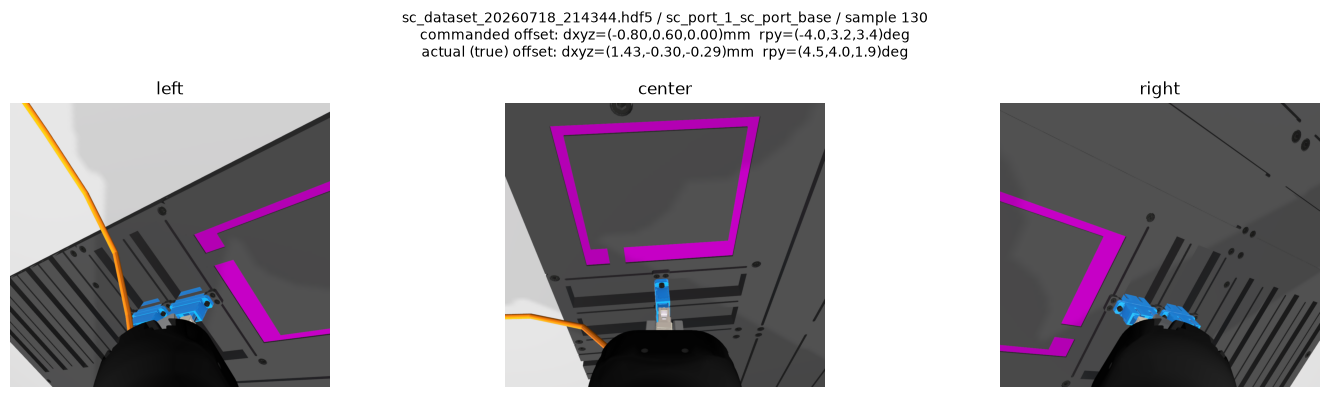

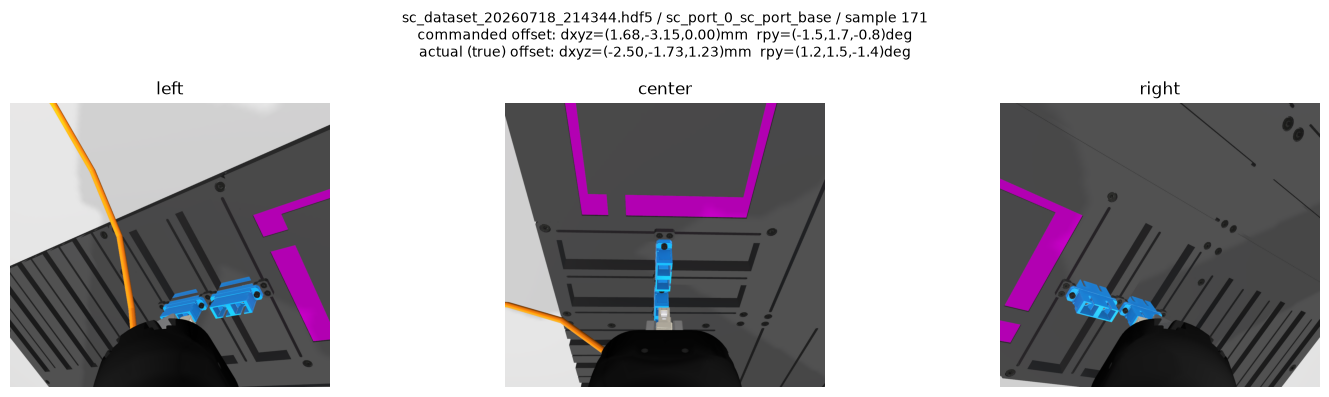

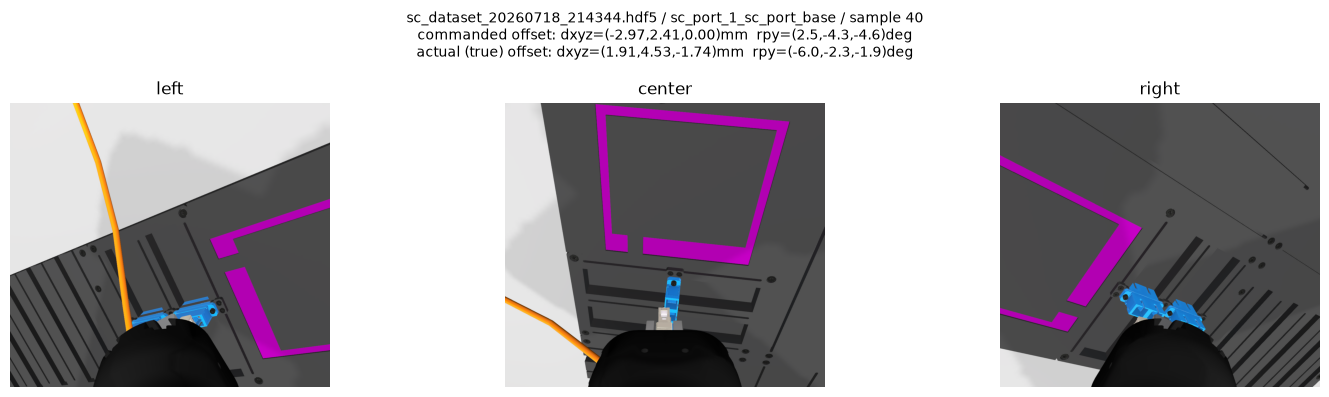

In [45]:
# Show a handful of random samples across the available files/ports.
rng = np.random.default_rng(CFG["seed"])
for _ in range(3):
    path = rng.choice(hdf5_paths)
    with h5py.File(path, "r", locking=False) as f:
        group_name = rng.choice(list(f.keys()))
        n = f[group_name]["tip_pose"].shape[0]
    idx = int(rng.integers(0, n))
    sample = load_sample(path, group_name, idx)
    plot_sample(sample, title=f"{os.path.basename(path)} / {group_name} / sample {idx}")

### 1.1 Set a fixed per-camera crop (ROI), per cable type

If the connector/port only occupies a small part of the frame, cropping to
that region before resizing to `CFG["image_size"]` lets the policy spend
its (small) input resolution on pixels that actually matter instead of
downsampling a lot of irrelevant background along with them.

Different cable/connector types (e.g. SFP vs. SC) sit in different parts of
the frame, so `CFG["crop"]` is keyed by cable type first, then camera:
`CFG["crop"][cable_type][cam] = (x0, y0, x1, y1)`, or `None` to leave that
camera uncropped for that cable type. Each sample's cable type comes from
its HDF5 group's `cable_type` attribute (set by `data_acquisition.py`), so
the right crop is applied automatically per-sample -- nothing else needs to
change if your dataset mixes cable types.

Edit `CFG["crop"]` above, then re-run the cell below. Set
`_preview_cable_type` to the cable type you want to check (e.g. `"sfp"` or
`"sc"`), or leave it `None` to preview whichever sample is found first. The
red rectangle on the top row shows the box on the full frame; the bottom
row shows what the model will actually see. Iterate until the ROI
comfortably covers the port across the range of poses in your data for
*that* cable type (check a few different `_preview_idx` values too, not
just one sample).

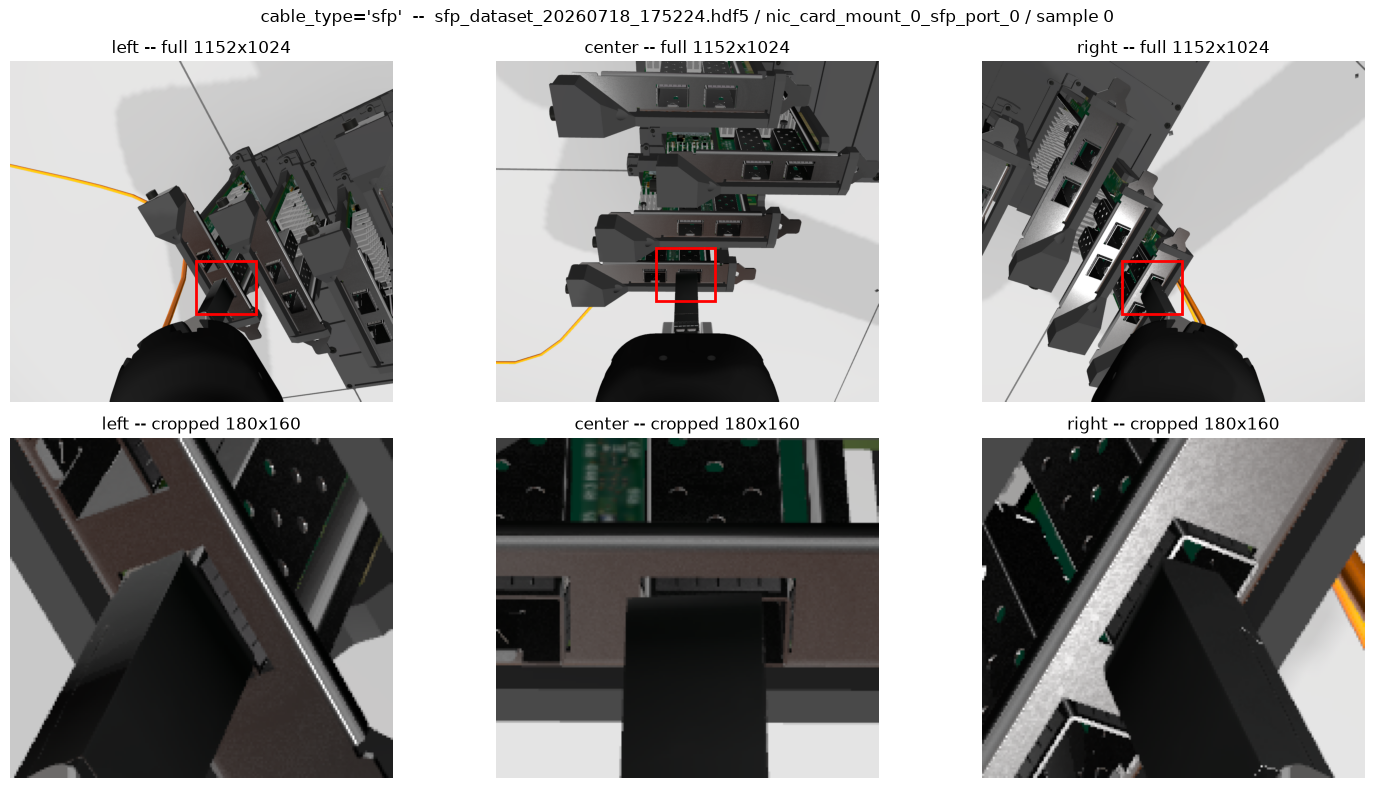

In [46]:
def find_sample_for_cable_type(hdf5_paths, cable_type=None):
    """Returns (path, group_name) for the first port group matching
    cable_type, or just the first group found if cable_type is None --
    lets you pick which cable type's crop to preview below."""
    for path in hdf5_paths:
        with h5py.File(path, "r", locking=False) as f:
            for group_name in f.keys():
                if cable_type is None or f[group_name].attrs.get("cable_type") == cable_type:
                    return path, group_name
    raise ValueError(f"no sample found for cable_type={cable_type!r}")


def show_crop_preview(path, group_name, idx, cfg):
    with h5py.File(path, "r", locking=False) as f:
        cable_type = f[group_name].attrs["cable_type"]
        raw_images = {cam: f[group_name]["images"][cam][idx] for cam in cfg["cams"]}

    fig, axes = plt.subplots(2, len(cfg["cams"]), figsize=(5 * len(cfg["cams"]), 8), squeeze=False)
    for col, cam in enumerate(cfg["cams"]):
        img_rgb = cv2.cvtColor(raw_images[cam], cv2.COLOR_BGR2RGB)
        box = resolve_crop_box(cfg["crop"], cable_type, cam)

        ax_full = axes[0][col]
        ax_full.imshow(img_rgb)
        ax_full.set_title(f"{cam} -- full {img_rgb.shape[1]}x{img_rgb.shape[0]}")
        ax_full.axis("off")
        if box is not None:
            x0, y0, x1, y1 = box
            ax_full.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                                             edgecolor="red", facecolor="none", linewidth=2))

        cropped = crop_image(img_rgb, box)
        ax_crop = axes[1][col]
        ax_crop.imshow(cropped)
        ax_crop.set_title(f"{cam} -- cropped {cropped.shape[1]}x{cropped.shape[0]}")
        ax_crop.axis("off")

    fig.suptitle(f"cable_type={cable_type!r}  --  {os.path.basename(path)} / {group_name} / sample {idx}")
    plt.tight_layout()
    plt.show()


# Set to "sfp" / "sc" / any other cable_type you have data for, or None to
# preview whichever sample is found first -- CFG["crop"] has a separate
# box per cable type, so check each one you actually have data for.
_preview_cable_type = "sfp"
_preview_path, _preview_group = find_sample_for_cable_type(hdf5_paths, _preview_cable_type)
_preview_idx = 0
show_crop_preview(_preview_path, _preview_group, _preview_idx, CFG)

### 1.2 Preview training augmentation (rotation + crop jitter)

`CFG["augment"]` is re-sampled every time a *training* sample is loaded, so re-running the cell below draws a fresh random rotation/crop-jitter each time -- a quick way to sanity-check the ranges before launching a long training run. This is what `train_ds` (section 2) will actually feed the model; the val/eval set always sees the plain fixed crop from 1.1 above, never these augmented variants.


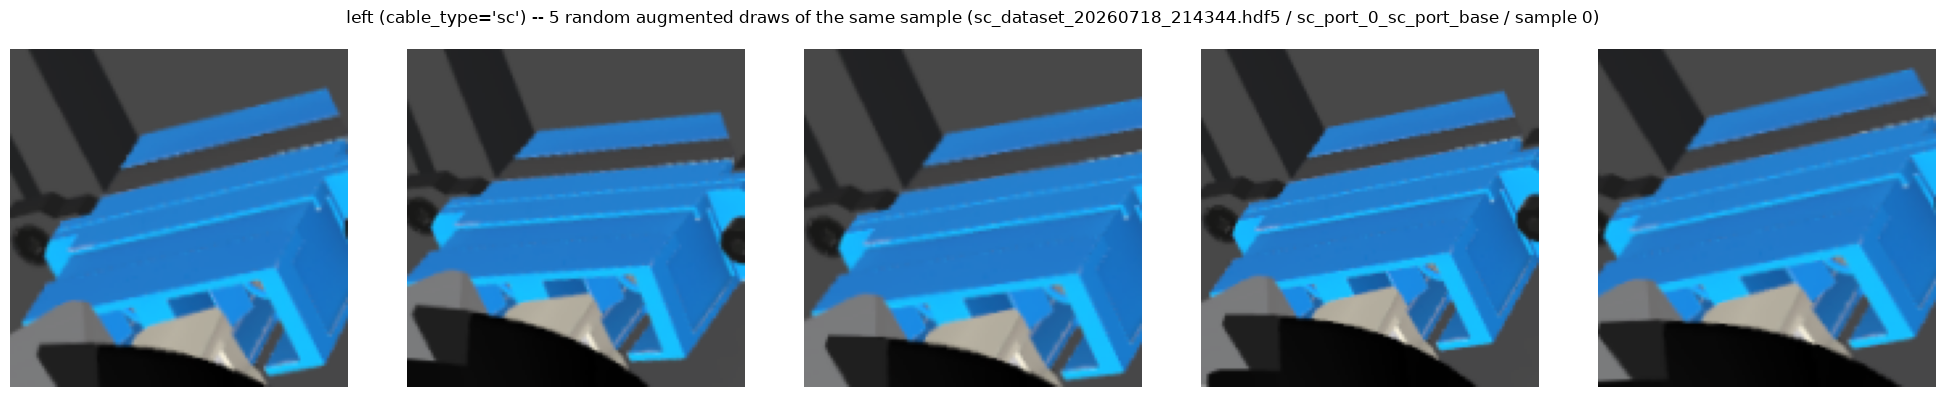

In [17]:
def show_augmentation_preview(path, group_name, idx, cfg, cam=None, n_variants=5):
    cam = cam or cfg["cams"][0]
    with h5py.File(path, "r", locking=False) as f:
        cable_type = f[group_name].attrs["cable_type"]
        raw_bgr = f[group_name]["images"][cam][idx]
    img_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
    box = resolve_crop_box(cfg["crop"], cable_type, cam)

    fig, axes = plt.subplots(1, n_variants, figsize=(4 * n_variants, 4))
    for ax in axes:
        deg = cfg["augment"]["rotation_deg"]
        center = None if box is None else ((box[0] + box[2]) / 2.0, (box[1] + box[3]) / 2.0)
        rotated = rotate_image(img_rgb, random.uniform(-deg, deg), center)
        jittered_box = jitter_crop_box(box, cfg["augment"]["crop_jitter_px"], rotated.shape)
        cropped = crop_image(rotated, jittered_box)
        resized = cv2.resize(cropped, (cfg["image_size"], cfg["image_size"]), interpolation=cv2.INTER_AREA)
        ax.imshow(resized)
        ax.axis("off")
    fig.suptitle(
        f"{cam} (cable_type={cable_type!r}) -- {n_variants} random augmented draws of the same sample "
        f"({os.path.basename(path)} / {group_name} / sample {idx})"
    )
    plt.tight_layout()
    plt.show()


show_augmentation_preview(_preview_path, _preview_group, _preview_idx, CFG)


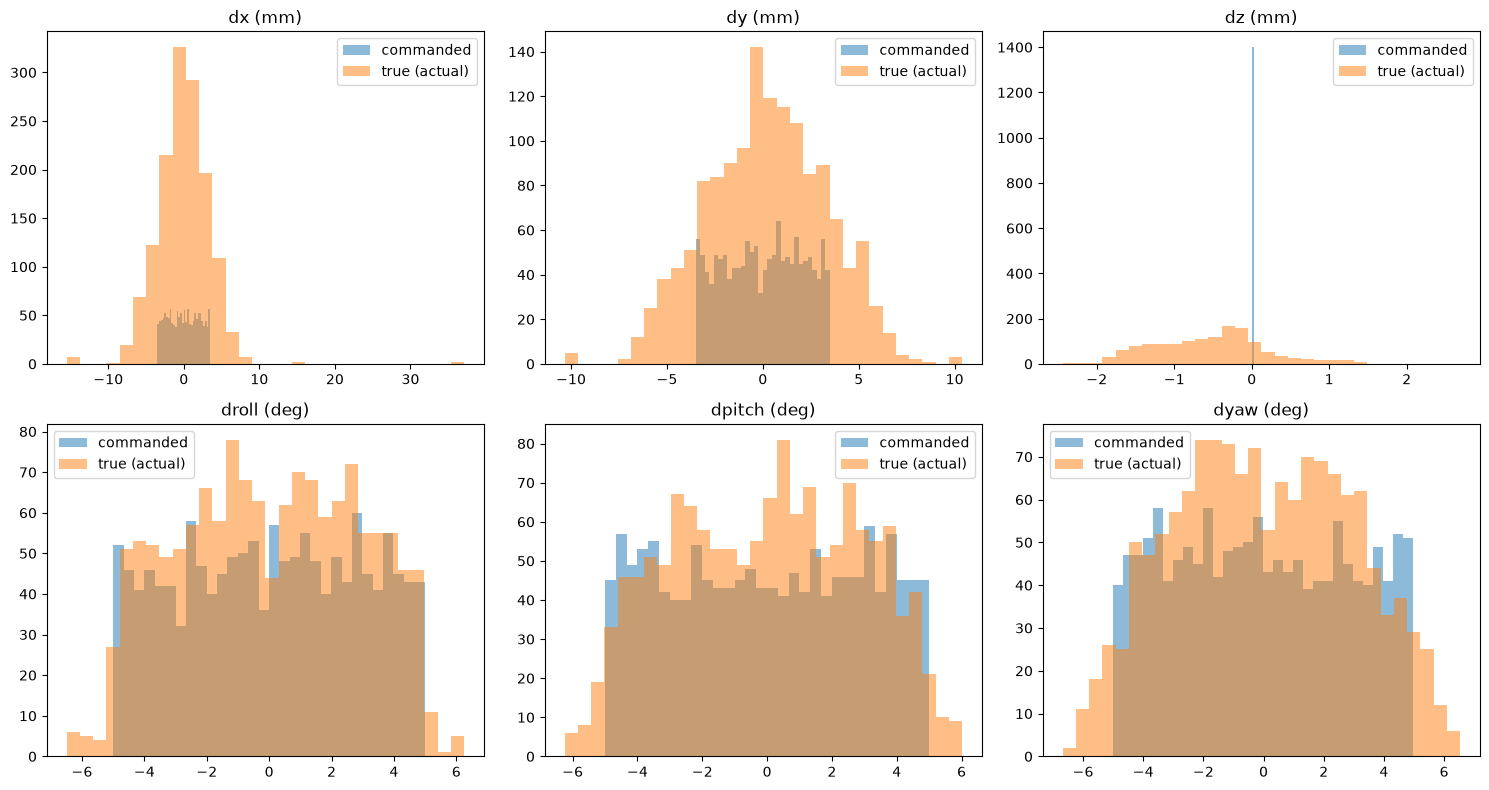

Total samples: 1400
True-offset mean/std per dim: [-3.8534625e-05  2.0126349e-04 -5.6062109e-04 -1.5569651e-03
 -1.2692390e-03 -1.6717490e-02] [3.5505954e-03 3.1128919e-03 7.1752362e-04 2.8569777e+00 2.8654220e+00
 2.9261127e+00]


In [18]:
# Sanity-check the offset distributions: commanded vs. actual (true). If the
# controller tracked perfectly these would coincide -- the spread between
# them is exactly the "impedance control could be a little off" slack that
# motivates using true_offset as the training target.
cmd_all, true_all = [], []
for path in hdf5_paths:
    with h5py.File(path, "r", locking=False) as f:
        for group_name in f.keys():
            g = f[group_name]
            n = g["tip_pose"].shape[0]
            cmd_all.append(g["offset"][:])
            tip = g["tip_pose"][:]
            port = g["port_pose"][:]
            true_all.append(np.stack([
                compute_relative_offset(tip[i, :3], tip[i, 3:], port[i, :3], port[i, 3:])
                for i in range(n)
            ]))
cmd_all = np.concatenate(cmd_all, axis=0)
true_all = np.concatenate(true_all, axis=0)

dim_names = ["dx (mm)", "dy (mm)", "dz (mm)", "droll (deg)", "dpitch (deg)", "dyaw (deg)"]
scale = np.array([1e3, 1e3, 1e3, 1.0, 1.0, 1.0])

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    ax.hist(cmd_all[:, i] * scale[i], bins=30, alpha=0.5, label="commanded")
    ax.hist(true_all[:, i] * scale[i], bins=30, alpha=0.5, label="true (actual)")
    ax.set_title(dim_names[i])
    ax.legend()
plt.tight_layout()
plt.show()

print(f"Total samples: {len(true_all)}")
print("True-offset mean/std per dim:", true_all.mean(0), true_all.std(0))

### 1.3 TF timing validation

How far did the tip/port pose lookup's own timestamp drift from the image
timestamp at capture time (`tip_pose_dt_s` / `port_pose_dt_s`, see
`data_acquisition.py`'s `_try_capture_sample`)? A large drift means the
recorded label may not match what the images actually show -- "latest" TF
is used at capture time (not an exact-time lookup) because ground-truth TF
publishing was observed lagging camera timestamps by up to ~0.75s under
real sim load, so this is measured rather than enforced. Also reports the
fraction of samples that reached the `settle_max_*` velocity thresholds
before `settle_timeout_s` (see `_wait_until_settled`), i.e. weren't
possibly captured mid-motion.

Datasets collected before these validation fields were added won't have
them -- those files/ports are skipped here rather than erroring.

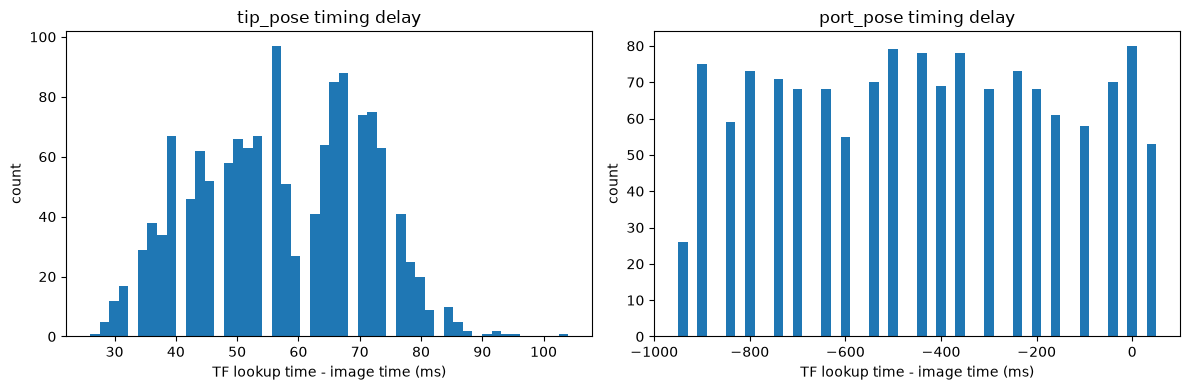

tip_pose_dt_s:  mean=57.4ms  std=13.6ms  max|dt|=104.0ms
port_pose_dt_s: mean=-439.2ms  std=290.7ms  max|dt|=950.0ms
settled: 100.0% of samples settled before settle_timeout_s


In [19]:
# --------------------------------------------------------------------------
# TF timing validation: histogram of (TF lookup timestamp - image timestamp)
# across every sample/port/file, plus the settled fraction. See markdown
# above for what this means and why it's a measurement, not a filter.
# --------------------------------------------------------------------------
tip_dt_all, port_dt_all, settled_all = [], [], []
n_skipped_groups = 0
for path in hdf5_paths:
    with h5py.File(path, "r", locking=False) as f:
        for group_name in f.keys():
            g = f[group_name]
            if "tip_pose_dt_s" not in g:
                n_skipped_groups += 1
                continue
            tip_dt_all.append(g["tip_pose_dt_s"][:])
            port_dt_all.append(g["port_pose_dt_s"][:])
            settled_all.append(g["settled"][:])

if n_skipped_groups:
    print(f"Skipped {n_skipped_groups} port group(s) with no TF-timing validation fields "
          f"(collected before this was added to data_acquisition.py)")

if not tip_dt_all:
    print("No tip_pose_dt_s/port_pose_dt_s fields found in any dataset -- "
          "recollect data with the current data_acquisition.py to get them.")
else:
    tip_dt_ms = np.concatenate(tip_dt_all) * 1e3
    port_dt_ms = np.concatenate(port_dt_all) * 1e3
    settled_all = np.concatenate(settled_all)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, dt_ms, name in zip(axes, [tip_dt_ms, port_dt_ms], ["tip_pose", "port_pose"]):
        ax.hist(dt_ms, bins=50)
        ax.set_xlabel("TF lookup time - image time (ms)")
        ax.set_ylabel("count")
        ax.set_title(f"{name} timing delay")
    plt.tight_layout()
    plt.show()

    print(f"tip_pose_dt_s:  mean={tip_dt_ms.mean():.1f}ms  std={tip_dt_ms.std():.1f}ms  "
          f"max|dt|={np.abs(tip_dt_ms).max():.1f}ms")
    print(f"port_pose_dt_s: mean={port_dt_ms.mean():.1f}ms  std={port_dt_ms.std():.1f}ms  "
          f"max|dt|={np.abs(port_dt_ms).max():.1f}ms")
    print(f"settled: {settled_all.mean() * 100:.1f}% of samples settled before settle_timeout_s")

## 2. PyTorch `Dataset` / `DataLoader`

`OffsetDataset` opens its HDF5 files lazily (on first `__getitem__` call in
each worker process), which is required for `DataLoader(num_workers>0)`:
`h5py.File` handles aren't safe to open before the worker processes fork.


In [20]:
def build_flat_index(paths):
    """List of (path, group_name, sample_idx) for every sample across every
    file/port, plus the port id each entry belongs to (for by-port splits)."""
    index, port_ids = [], []
    for path in paths:
        with h5py.File(path, "r", locking=False) as f:
            for group_name in f.keys():
                n = f[group_name]["tip_pose"].shape[0]
                for i in range(n):
                    index.append((path, group_name, i))
                    port_ids.append(group_name)
    return index, port_ids


def filter_index_by_cable_type(index, cable_types):
    """Keeps only entries whose HDF5 group's cable_type attribute is in
    cable_types (e.g. ["sc"] to train/evaluate only on SC-plug data).
    Groups by (path, group_name) so each file/port's attrs are only read
    once."""
    by_file_group = {}
    for i, (path, group_name, idx) in enumerate(index):
        by_file_group.setdefault((path, group_name), []).append(i)

    keep = np.zeros(len(index), dtype=bool)
    for (path, group_name), entry_idxs in by_file_group.items():
        with h5py.File(path, "r", locking=False) as f:
            cable_type = f[group_name].attrs.get("cable_type")
        if cable_type in cable_types:
            for i in entry_idxs:
                keep[i] = True

    filtered = [index[i] for i in range(len(index)) if keep[i]]
    print(f"cable_type filter ({cable_types}): kept {len(filtered)}/{len(index)} samples")
    return filtered


def filter_index_by_xy_offset(index, max_offset_m):
    """Drops entries whose true (dx, dy) offset -- computed the same way
    as the training target, from actual tip_pose/port_pose, not the
    commanded offset -- has |dx| or |dy| exceeding max_offset_m. Groups by
    (path, group_name) so each file/port is only opened once."""
    by_file_group = {}
    for i, (path, group_name, idx) in enumerate(index):
        by_file_group.setdefault((path, group_name), []).append((i, idx))

    keep = np.zeros(len(index), dtype=bool)
    for (path, group_name), entries in by_file_group.items():
        with h5py.File(path, "r", locking=False) as f:
            g = f[group_name]
            sample_idxs = [idx for _, idx in entries]
            tip_poses = g["tip_pose"][:][sample_idxs]
            port_poses = g["port_pose"][:][sample_idxs]
        for (i, _), tip_pose, port_pose in zip(entries, tip_poses, port_poses):
            offset = compute_relative_offset(tip_pose[:3], tip_pose[3:], port_pose[:3], port_pose[3:])
            keep[i] = abs(offset[0]) <= max_offset_m and abs(offset[1]) <= max_offset_m

    filtered = [index[i] for i in range(len(index)) if keep[i]]
    print(f"xy-offset filter: dropped {len(index) - len(filtered)}/{len(index)} samples "
          f"(|dx| or |dy| > {max_offset_m * 1e3:.1f}mm)")
    return filtered


def cable_type_tag(cfg):
    """Short filename-safe tag for the cable types currently selected via
    CFG["filter"]["cable_types"] -- e.g. ["sc"] -> "sc", ["sfp", "sc"] ->
    "sc-sfp", None -> "all". Baked into checkpoint filenames so training
    with a different cable_types filter (e.g. switching from all-data to
    SC-only) saves to a separate file instead of silently overwriting the
    previous run's checkpoint."""
    cable_types = cfg["filter"]["cable_types"]
    if isinstance(cable_types, str):
        raise TypeError(
            f'CFG["filter"]["cable_types"] must be a list (e.g. ["sc"]), not the bare '
            f"string {cable_types!r} -- a string iterates character-by-character in "
            f"Python and silently produces a nonsense tag."
        )
    return "-".join(sorted(cable_types)) if cable_types else "all"


def split_index(index, port_ids, val_fraction, split_mode, seed):
    rng = np.random.default_rng(seed)
    n = len(index)
    if split_mode == "by_port":
        unique_ports = sorted(set(port_ids))
        if len(unique_ports) < 2:
            print(f"by_port split needs >=2 ports, only found {unique_ports}; falling back to random split")
            perm = rng.permutation(n)
            n_val = round(n * val_fraction)
            return [index[i] for i in perm[n_val:]], [index[i] for i in perm[:n_val]]
        n_val_ports = min(len(unique_ports) - 1, max(1, round(len(unique_ports) * val_fraction)))
        val_ports = set(rng.choice(unique_ports, size=n_val_ports, replace=False))
        train_idx = [i for i in range(n) if port_ids[i] not in val_ports]
        val_idx = [i for i in range(n) if port_ids[i] in val_ports]
        print(f"by_port split -- val ports: {sorted(val_ports)}")
    else:
        perm = rng.permutation(n)
        n_val = round(n * val_fraction)
        val_idx = perm[:n_val].tolist()
        train_idx = perm[n_val:].tolist()
    return [index[i] for i in train_idx], [index[i] for i in val_idx]


class OffsetDataset(Dataset):
    def __init__(self, index, image_size, cams, crop=None, augment=False, target_mean=None, target_std=None):
        self.index = index
        self.image_size = image_size
        self.cams = cams
        self.crop = crop or {}
        self.augment = augment
        self.target_mean = target_mean
        self.target_std = target_std
        self._files = {}

    def _file(self, path):
        f = self._files.get(path)
        if f is None:
            f = h5py.File(path, "r", locking=False)
            self._files[path] = f
        return f

    def __len__(self):
        return len(self.index)

    def _load_image(self, raw_bgr, cam, cable_type):
        img = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
        box = resolve_crop_box(self.crop, cable_type, cam)
        if self.augment:
            deg = CFG["augment"]["rotation_deg"]
            center = None if box is None else ((box[0] + box[2]) / 2.0, (box[1] + box[3]) / 2.0)
            img = rotate_image(img, random.uniform(-deg, deg), center)
            box = jitter_crop_box(box, CFG["augment"]["crop_jitter_px"], img.shape)
        img = crop_image(img, box)
        img = cv2.resize(img, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        img = img.astype(np.float32) / 255.0
        img = (img - IMAGENET_MEAN) / IMAGENET_STD
        return torch.from_numpy(img.transpose(2, 0, 1))

    def __getitem__(self, i):
        path, group_name, idx = self.index[i]
        g = self._file(path)[group_name]
        cable_type = g.attrs["cable_type"]

        images = torch.stack(
            [self._load_image(g["images"][cam][idx], cam, cable_type) for cam in self.cams], dim=0
        )

        tip_pose = g["tip_pose"][idx]
        port_pose = g["port_pose"][idx]
        target = compute_relative_offset(tip_pose[:3], tip_pose[3:], port_pose[:3], port_pose[3:])
        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std
        return images, torch.from_numpy(target.astype(np.float32))


def compute_target_stats(index, cams):
    """Mean/std of the raw (physical-unit) target over `index`, used to
    standardize regression targets so all 6 dims contribute comparably to
    the loss (translation is in meters, rotation in degrees). Also returns
    the raw per-sample targets themselves (same order as `index`) so callers
    don't have to redo this same full pass just to look at individual
    samples -- see the small-error oversampling weights in section 2."""
    raw_ds = OffsetDataset(index, image_size=CFG["image_size"], cams=cams, crop=CFG["crop"], augment=False)
    targets = np.stack([raw_ds[i][1].numpy() for i in range(len(raw_ds))])
    return targets.mean(0).astype(np.float32), targets.std(0).astype(np.float32), targets


def unnormalize(x, mean, std):
    mean_t = torch.as_tensor(mean, dtype=x.dtype, device=x.device)
    std_t = torch.as_tensor(std, dtype=x.dtype, device=x.device)
    return x * std_t + mean_t

### 2.1 Filter out large-offset outliers

`CFG["filter"]["max_xy_offset_m"]` drops any sample whose *true* offset (the actual controller-measured `tip_pose` vs. `port_pose`, same quantity used as the training target -- not the commanded `offset`) has `|dx|` or `|dy|` beyond this threshold, before the train/val split. These are typically failed settles where the tip ended up far from the port; keeping them in would ask a residual policy -- meant to correct *small* final-approach errors -- to also model rare large excursions, which pulls the small-offset predictions it actually needs to be accurate on off center. Set to `None` to disable.


In [30]:
flat_index, port_ids = build_flat_index(hdf5_paths)
print(f"total samples before filtering: {len(flat_index)}")

if CFG["filter"]["cable_types"] is not None:
    flat_index = filter_index_by_cable_type(flat_index, CFG["filter"]["cable_types"])
    port_ids = [group_name for (_, group_name, _) in flat_index]

if CFG["filter"]["max_xy_offset_m"] is not None:
    flat_index = filter_index_by_xy_offset(flat_index, CFG["filter"]["max_xy_offset_m"])
    port_ids = [group_name for (_, group_name, _) in flat_index]

train_index, val_index = split_index(flat_index, port_ids, CFG["val_fraction"], CFG["split_mode"], CFG["seed"])
print(f"train samples: {len(train_index)}  val samples: {len(val_index)}")

TARGET_MEAN, TARGET_STD, TRAIN_TARGETS_RAW = compute_target_stats(train_index, CFG["cams"])
print("target mean:", TARGET_MEAN)
print("target std: ", TARGET_STD)

# Augmentation is only ever applied to the training split -- val stays on
# the fixed, un-augmented crop so evaluation is deterministic/comparable
# across runs.
train_ds = OffsetDataset(train_index, CFG["image_size"], CFG["cams"], CFG["crop"],
                          CFG["augment"]["enabled"], TARGET_MEAN, TARGET_STD)
val_ds = OffsetDataset(val_index, CFG["image_size"], CFG["cams"], CFG["crop"],
                        False, TARGET_MEAN, TARGET_STD)


def seed_worker(worker_id):
    """Reseeds numpy/random in each DataLoader worker process. Without this,
    forked workers inherit identical RNG state and produce correlated
    (partly duplicated) augmentation across workers -- see PyTorch's notes
    on randomness in multi-process data loading."""
    worker_seed = (torch.initial_seed() + worker_id) % (2 ** 32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


# Oversample small-error training samples (see CFG["small_error_oversample"])
# so the model gets more practice exactly where a residual policy needs to
# be most precise, instead of a uniform draw over the whole offset range.
# Position-magnitude is computed once from TRAIN_TARGETS_RAW (same order as
# train_index/train_ds), so this doesn't need another pass over the dataset.
# Applies to both the regressor and diffusion training loops below, since
# they both consume this same train_loader.
_train_pos_mag_mm = np.linalg.norm(TRAIN_TARGETS_RAW[:, :3], axis=1) * 1e3
_small_error_mask = _train_pos_mag_mm < CFG["small_error_oversample"]["threshold_mm"]
_sample_weights = np.where(_small_error_mask, CFG["small_error_oversample"]["weight_multiplier"], 1.0)
print(f"small-error oversampling: {_small_error_mask.sum()}/{len(_small_error_mask)} train samples "
      f"(< {CFG['small_error_oversample']['threshold_mm']}mm) get weight "
      f"{CFG['small_error_oversample']['weight_multiplier']}x")

train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.as_tensor(_sample_weights, dtype=torch.double),
    num_samples=len(train_ds),
    replacement=True,
)
train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], sampler=train_sampler,
                           num_workers=CFG["num_workers"], pin_memory=True, drop_last=True,
                           worker_init_fn=seed_worker if CFG["num_workers"] > 0 else None)
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False,
                         num_workers=CFG["num_workers"], pin_memory=True)

_imgs, _tgt = train_ds[0]
print("image batch item shape:", _imgs.shape, "target shape:", _tgt.shape)

total samples before filtering: 1400
cable_type filter (['sfp']): kept 1000/1400 samples
xy-offset filter: dropped 29/1000 samples (|dx| or |dy| > 7.5mm)
train samples: 825  val samples: 146
target mean: [ 2.0670859e-05  8.2156032e-05 -6.5168046e-04  3.0674083e-02
 -3.3071119e-02 -9.1353551e-02]
target std:  [3.1817746e-03 3.1514650e-03 5.5054558e-04 2.8729310e+00 2.8270626e+00
 2.8977754e+00]
small-error oversampling: 112/825 train samples (< 2.0mm) get weight 3.0x
image batch item shape: torch.Size([3, 3, 128, 128]) target shape: torch.Size([6])


## 3. Model 1 -- CNN + MLP regressor (MSE)

A small ResNet18 backbone (ImageNet-pretrained) is shared (weight-tied)
across the 3 camera views; the concatenated per-view features feed an MLP
that regresses the standardized 6-DoF target, trained with Adam(W) + MSE.

**Freeze or fine-tune the pretrained backbone?** With a dataset this size
(hundreds to low thousands of samples per port), fine-tuning all of
ResNet18 risks overfitting its features to this specific simulated scene
and mostly wastes compute -- the generic ImageNet low-level features (edges,
textures, gradients) already transfer well to recognizing a connector/port.
`CFG["freeze_backbone"] = True` freezes the backbone (including its
BatchNorm running stats) and only trains the projection layer + MLP head, a
"linear probe" on top of frozen features; this is the recommended default
here. Once you have substantially more data (more ports, more randomized
lighting/backgrounds), it's worth setting it to `False` to let the backbone
adapt beyond generic ImageNet features -- watch the val loss in TensorBoard
when you do, fine-tuning overfits faster than the frozen setup.


In [31]:
class SharedViewEncoder(nn.Module):
    def __init__(self, out_dim, pretrained=True, freeze_backbone=False):
        super().__init__()
        weights = torchvision.models.ResNet18_Weights.DEFAULT if pretrained else None
        backbone = torchvision.models.resnet18(weights=weights)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.proj = nn.Linear(512, out_dim)

        self.freeze_backbone = freeze_backbone
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
            self.backbone.eval()

    def train(self, mode=True):
        super().train(mode)
        if self.freeze_backbone:
            self.backbone.eval()  # keep frozen BatchNorm running stats fixed
        return self

    def forward(self, x):
        return self.proj(self.backbone(x))


class MultiViewRegressor(nn.Module):
    def __init__(self, num_cams, feat_dim, hidden, out_dim=6, freeze_backbone=False):
        super().__init__()
        self.num_cams = num_cams
        self.encoder = SharedViewEncoder(feat_dim, freeze_backbone=freeze_backbone)
        self.mlp = nn.Sequential(
            nn.Linear(feat_dim * num_cams, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim),
        )

    def forward(self, images):
        # images: (B, num_cams, 3, H, W)
        b, n, c, h, w = images.shape
        feats = self.encoder(images.reshape(b * n, c, h, w)).reshape(b, n * self.encoder.proj.out_features)
        return self.mlp(feats)

In [32]:
class EarlyStopper:
    """Stops training once val loss hasn't improved for `patience` epochs."""

    def __init__(self, patience):
        self.patience = patience
        self.best = float("inf")
        self.num_bad_epochs = 0

    def step(self, val_loss):
        if val_loss < self.best:
            self.best = val_loss
            self.num_bad_epochs = 0
        else:
            self.num_bad_epochs += 1
        return self.num_bad_epochs > self.patience


def mae_per_dim(preds_phys, targets_phys):
    return (preds_phys - targets_phys).abs().mean(dim=0)


def run_regressor_epoch(model, loader, optimizer, device, train):
    model.train(train)
    total_loss, n_seen = 0.0, 0
    all_preds, all_targets = [], []
    with torch.set_grad_enabled(train):
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            preds = model(images)
            loss = F.mse_loss(preds, targets)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            n_seen += images.size(0)
            all_preds.append(preds.detach().cpu())
            all_targets.append(targets.detach().cpu())
    return total_loss / n_seen, torch.cat(all_preds), torch.cat(all_targets)


def train_regressor(cfg, train_loader, val_loader, target_mean, target_std, device):
    model = MultiViewRegressor(
        len(cfg["cams"]), cfg["reg_feat_dim"], cfg["reg_hidden"], freeze_backbone=cfg["freeze_backbone"]
    ).to(device)
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["reg_epochs"])
    early_stopper = EarlyStopper(cfg["early_stop_patience"])

    run_name = "regression_" + datetime.now().strftime("%Y%m%d_%H%M%S")
    writer = SummaryWriter(log_dir=os.path.join(cfg["log_dir"], run_name))
    ckpt_path = os.path.join(cfg["ckpt_dir"], f"regressor_best_{cable_type_tag(cfg)}.pt")

    best_val = float("inf")
    for epoch in tqdm(range(cfg["reg_epochs"]), desc="regressor"):
        train_loss, _, _ = run_regressor_epoch(model, train_loader, optimizer, device, train=True)
        val_loss, val_preds, val_targets = run_regressor_epoch(model, val_loader, optimizer, device, train=False)
        scheduler.step()

        val_preds_phys = unnormalize(val_preds, target_mean, target_std)
        val_targets_phys = unnormalize(val_targets, target_mean, target_std)
        mae = mae_per_dim(val_preds_phys, val_targets_phys)

        writer.add_scalar("loss/train", train_loss, epoch)
        writer.add_scalar("loss/val", val_loss, epoch)
        for name, value in zip(["dx_m", "dy_m", "dz_m", "droll_deg", "dpitch_deg", "dyaw_deg"], mae.tolist()):
            writer.add_scalar(f"val_mae/{name}", value, epoch)

        if val_loss < best_val:
            best_val = val_loss
            torch.save({
                "model": model.state_dict(),
                "target_mean": target_mean,
                "target_std": target_std,
                "val_loss": best_val,
            }, ckpt_path)

        if epoch % 5 == 0 or epoch == cfg["reg_epochs"] - 1:
            print(f"[regressor] epoch {epoch:03d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
                  f"mae(xyz mm)=({mae[0]*1e3:.2f},{mae[1]*1e3:.2f},{mae[2]*1e3:.2f})  "
                  f"mae(rpy deg)=({mae[3]:.2f},{mae[4]:.2f},{mae[5]:.2f})")

        if early_stopper.step(val_loss):
            print(f"[regressor] early stopping at epoch {epoch:03d} "
                  f"(no val improvement for {cfg['early_stop_patience']} epochs)")
            break

    writer.close()
    # Reload the best (not necessarily last) checkpoint, since early stopping
    # means the final epoch may already be past the point of best val loss.
    best_ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(best_ckpt["model"])
    return model, ckpt_path

In [33]:
if "regressor" in CFG["models_to_run"]:
    regressor, regressor_ckpt_path = train_regressor(
        CFG, train_loader, val_loader, TARGET_MEAN, TARGET_STD, DEVICE
    )
else:
    print("Skipping regressor training ('regressor' not in CFG['models_to_run']).")
    regressor, regressor_ckpt_path = None, None

regressor:   0%|          | 0/200 [00:00<?, ?it/s]

Exception ignored in: <function WeakValueDictionary.__init__.<locals>.remove at 0x743f983f8400>
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 113, in remove
    _atomic_removal(self.data, wr.key)
KeyboardInterrupt: 


KeyboardInterrupt: 

### 3.1 Regressor evaluation

Predicted-vs-true scatter per dimension (perfect predictions lie on the
diagonal), error histograms, and a few qualitative examples.


In [34]:
# Load the best-val-loss checkpoint from disk rather than reusing whatever
# is in memory -- makes this section (and everything below it) runnable on
# its own, e.g. after a kernel restart, without rerunning training.
def load_regressor_checkpoint(ckpt_path, cfg, device):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = MultiViewRegressor(
        len(cfg["cams"]), cfg["reg_feat_dim"], cfg["reg_hidden"], freeze_backbone=cfg["freeze_backbone"]
    ).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    return model, ckpt["target_mean"], ckpt["target_std"], ckpt.get("val_loss")


if "regressor" in CFG["models_to_run"]:
    regressor_ckpt_path = os.path.join(CFG["ckpt_dir"], f"regressor_best_{cable_type_tag(CFG)}.pt")
    regressor, _reg_ckpt_target_mean, _reg_ckpt_target_std, _reg_ckpt_val_loss = load_regressor_checkpoint(
        regressor_ckpt_path, CFG, DEVICE
    )
    if not (np.allclose(_reg_ckpt_target_mean, TARGET_MEAN) and np.allclose(_reg_ckpt_target_std, TARGET_STD)):
        print("WARNING: this checkpoint's saved target-normalization stats differ from the "
              "TARGET_MEAN/TARGET_STD computed in section 2 -- it was likely trained on a "
              "different data split/config than what's currently loaded, so the physical-unit "
              "predictions below (which unnormalize with the current TARGET_MEAN/TARGET_STD) "
              "may be wrong for this checkpoint.")
    print(f"Loaded best regressor checkpoint from {regressor_ckpt_path} (val_loss={_reg_ckpt_val_loss})")
else:
    print("Skipping regressor evaluation ('regressor' not in CFG['models_to_run']).")
    regressor = None

Loaded best regressor checkpoint from /home/intrinsic/ws_aic/src/aic/aic_solution/dataset/checkpoints/regressor_best_sfp.pt (val_loss=0.1438044889592657)


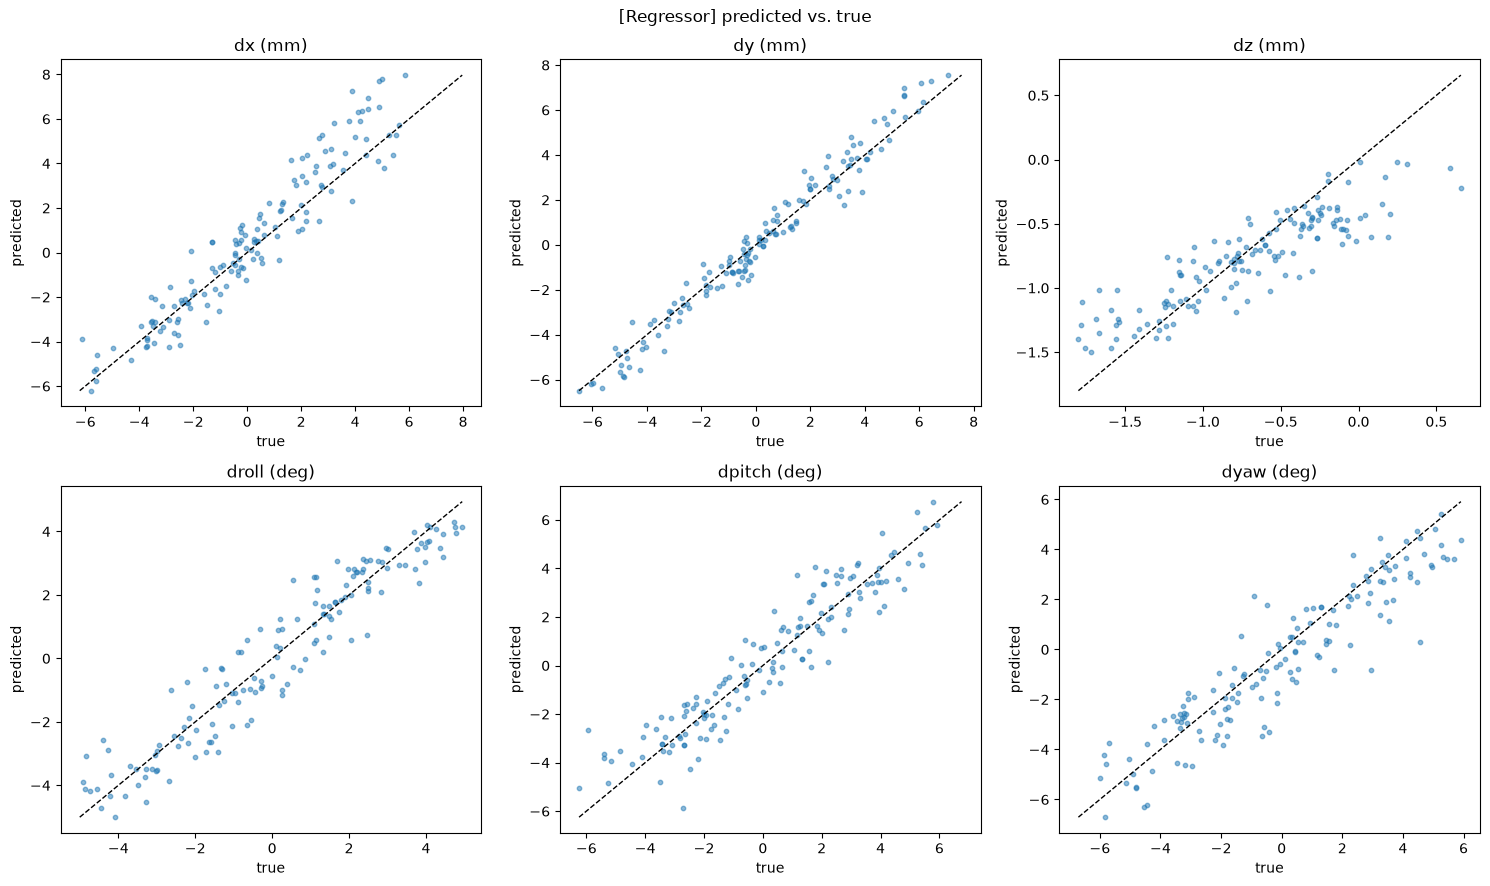

  MAE dx (mm): 0.893
  MAE dy (mm): 0.499
  MAE dz (mm): 0.225
  MAE droll (deg): 0.638
  MAE dpitch (deg): 0.799
  MAE dyaw (deg): 0.949


In [35]:
@torch.no_grad()
def collect_predictions(model, loader, device, target_mean, target_std):
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in loader:
        preds = model(images.to(device)).cpu()
        all_preds.append(preds)
        all_targets.append(targets)
    preds_phys = unnormalize(torch.cat(all_preds), target_mean, target_std).numpy()
    targets_phys = unnormalize(torch.cat(all_targets), target_mean, target_std).numpy()
    return preds_phys, targets_phys


def plot_pred_vs_true(preds_phys, targets_phys, dim_names, scale, title_prefix=""):
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for i, ax in enumerate(axes.flat):
        p, t = preds_phys[:, i] * scale[i], targets_phys[:, i] * scale[i]
        ax.scatter(t, p, s=10, alpha=0.5)
        lims = [min(t.min(), p.min()), max(t.max(), p.max())]
        ax.plot(lims, lims, "k--", linewidth=1)
        ax.set_xlabel("true")
        ax.set_ylabel("predicted")
        ax.set_title(dim_names[i])
    fig.suptitle(f"{title_prefix} predicted vs. true")
    plt.tight_layout()
    plt.show()

    mae = np.abs(preds_phys - targets_phys).mean(0) * scale
    for name, m in zip(dim_names, mae):
        print(f"  MAE {name}: {m:.3f}")


dim_names = ["dx (mm)", "dy (mm)", "dz (mm)", "droll (deg)", "dpitch (deg)", "dyaw (deg)"]
scale = np.array([1e3, 1e3, 1e3, 1.0, 1.0, 1.0])

if regressor is not None:
    reg_preds_phys, reg_targets_phys = collect_predictions(regressor, val_loader, DEVICE, TARGET_MEAN, TARGET_STD)
    plot_pred_vs_true(reg_preds_phys, reg_targets_phys, dim_names, scale, title_prefix="[Regressor]")
else:
    reg_preds_phys, reg_targets_phys = None, None
    print("Skipping regressor evaluation plots (regressor is None).")

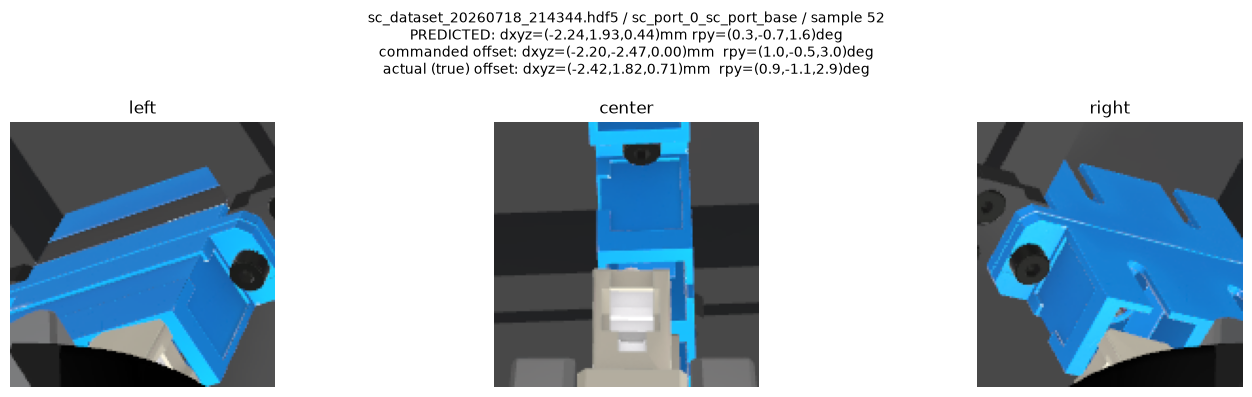

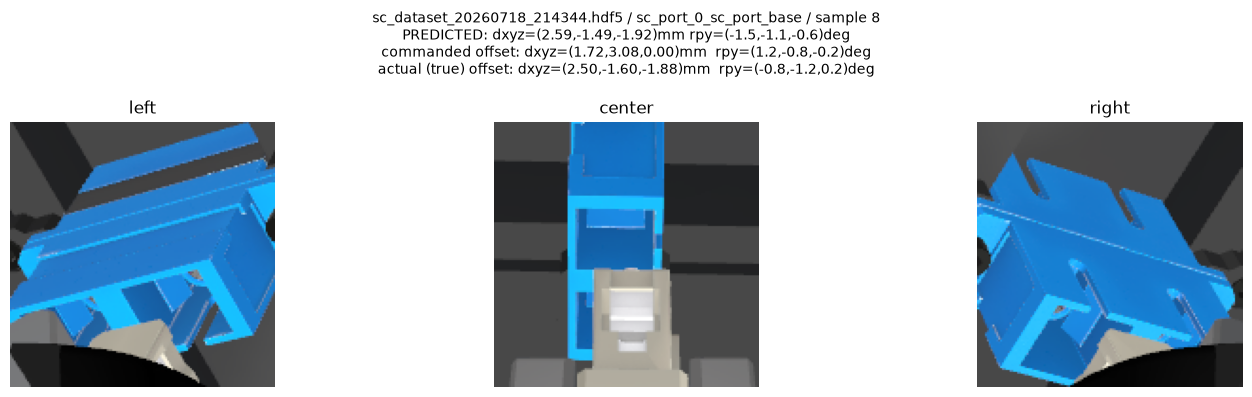

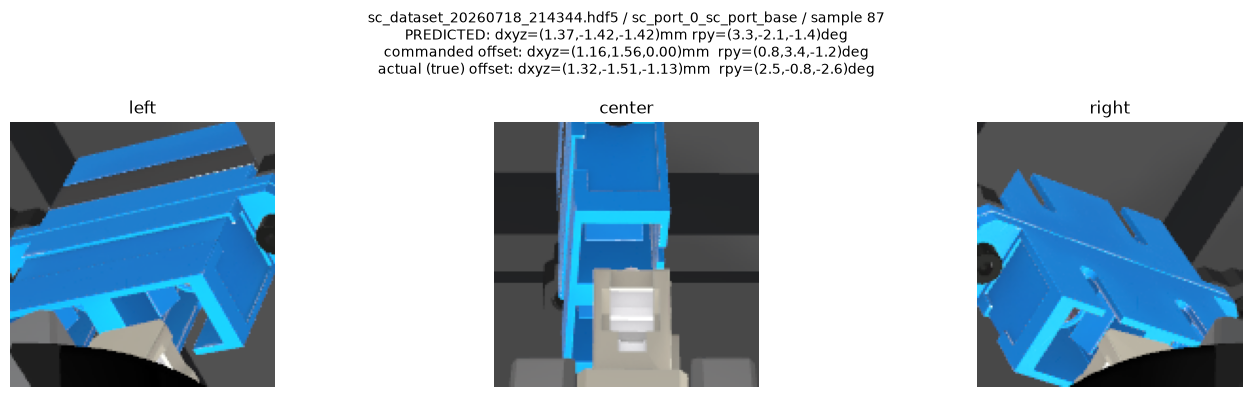

In [16]:
# A few qualitative examples: images + predicted vs. true offset as text.
@torch.no_grad()
def show_qualitative_examples(model, dataset, device, target_mean, target_std, n=3):
    model.eval()
    rng = np.random.default_rng(CFG["seed"] + 1)
    for _ in range(n):
        i = int(rng.integers(0, len(dataset)))
        path, group_name, idx = dataset.index[i]
        images, target_norm = dataset[i]
        pred_norm = model(images.unsqueeze(0).to(device)).cpu()[0]
        pred_phys = unnormalize(pred_norm, target_mean, target_std).numpy()
        true_phys = unnormalize(target_norm, target_mean, target_std).numpy()

        raw = load_sample(path, group_name, idx, crop=CFG["crop"])
        plot_sample(
            {**raw, "offset_cmd": raw["offset_cmd"], "true_offset": true_phys},
            title=(
                f"{os.path.basename(path)} / {group_name} / sample {idx}\n"
                f"PREDICTED: dxyz=({pred_phys[0]*1e3:.2f},{pred_phys[1]*1e3:.2f},{pred_phys[2]*1e3:.2f})mm "
                f"rpy=({pred_phys[3]:.1f},{pred_phys[4]:.1f},{pred_phys[5]:.1f})deg"
            ),
        )


if regressor is not None:
    show_qualitative_examples(regressor, val_ds, DEVICE, TARGET_MEAN, TARGET_STD)
else:
    print("Skipping regressor qualitative examples (regressor is None).")

## 4. Model 2 -- Diffusion policy

A conditional DDPM (Ho et al. 2020) over the 6-DoF offset vector: instead
of directly regressing the offset, the model learns to denoise a random
vector into the offset, conditioned on the same multi-view image features.
Regression to MSE effectively predicts the *mean* of the target
distribution; diffusion can represent multi-modal distributions instead
(useful if, e.g., the connector can settle against either side of a
mechanical stop). Uses the same `CFG["freeze_backbone"]` setting as the regressor above, but
its own `CFG["diff_early_stop_patience"]` -- diffusion's val loss is a
denoising MSE on random noise targets, noisier epoch-to-epoch than the
regressor's direct loss, so it may need a different patience.


> **Why the diffusion model was underperforming**: with `num_diffusion_steps=100` and the original Ho et al. beta range (`1e-4` to `2e-2`, tuned for **1000** steps), the forward noising process doesn't actually reach pure noise by the last step -- `alphas_cumprod[-1] ~= 0.36`, i.e. `x_T` still retains ~60% of the original signal (`sqrt_alphas_cumprod[-1] ~= 0.60`). But `diffusion_sample()` starts from `torch.randn(...)`, pure `N(0, 1)` noise -- a distribution the model was never trained to denoise from, since at training time `x_T` was always `0.60 * x0 + 0.80 * noise`, not pure noise. Every sample then gets denoised from the wrong starting point, which is consistent with the diffusion model's val MAE (section 4.1) landing close to just predicting the marginal mean -- it's not learning to ignore the images, its *sampling procedure* starts from an out-of-distribution point no matter how well the denoiser is trained.
>
> **Fix**: `CFG["diff_beta_end"]` is now `0.2` (10x the original), which pushes `alphas_cumprod[-1]` down to `~2e-5` -- `x_T` is then effectively indistinguishable from `N(0, 1)`, matching what `diffusion_sample()` actually starts from. (Increasing `num_diffusion_steps` back toward ~1000 with the original `beta_end=0.02` would fix the same issue, at the cost of ~10x slower sampling; scaling `beta_end` up is the cheaper fix for a small 6-DoF action space like this one.) Retrain after this change -- checkpoints saved before the fix were trained against the broken schedule.


In [17]:
def make_beta_schedule(num_steps, beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start, beta_end, num_steps)


class DiffusionSchedule:
    def __init__(self, num_steps, device, beta_start=1e-4, beta_end=2e-2):
        self.num_steps = num_steps
        self.betas = make_beta_schedule(num_steps, beta_start, beta_end).to(device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x0, t, noise):
        s1 = self.sqrt_alphas_cumprod[t].unsqueeze(-1)
        s2 = self.sqrt_one_minus_alphas_cumprod[t].unsqueeze(-1)
        return s1 * x0 + s2 * noise


def timestep_embedding(t, dim):
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device, dtype=torch.float32) / half)
    args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
    emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
    if dim % 2 == 1:
        emb = F.pad(emb, (0, 1))
    return emb


class DiffusionActionModel(nn.Module):
    def __init__(self, num_cams, feat_dim, hidden, time_dim, action_dim=6, freeze_backbone=False):
        super().__init__()
        self.num_cams = num_cams
        self.time_dim = time_dim
        self.encoder = SharedViewEncoder(feat_dim, freeze_backbone=freeze_backbone)
        cond_dim = feat_dim * num_cams
        self.net = nn.Sequential(
            nn.Linear(action_dim + cond_dim + time_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, action_dim),
        )

    def encode_images(self, images):
        b, n, c, h, w = images.shape
        return self.encoder(images.reshape(b * n, c, h, w)).reshape(b, n * self.encoder.proj.out_features)

    def forward(self, x_t, t, cond_feats):
        temb = timestep_embedding(t, self.time_dim)
        return self.net(torch.cat([x_t, cond_feats, temb], dim=1))

In [18]:
def run_diffusion_epoch(model, schedule, loader, optimizer, device, train):
    model.train(train)
    total_loss, n_seen = 0.0, 0
    with torch.set_grad_enabled(train):
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            cond = model.encode_images(images)
            t = torch.randint(0, schedule.num_steps, (targets.size(0),), device=device)
            noise = torch.randn_like(targets)
            x_t = schedule.q_sample(targets, t, noise)
            eps_hat = model(x_t, t, cond)
            loss = F.mse_loss(eps_hat, noise)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            n_seen += images.size(0)
    return total_loss / n_seen


@torch.no_grad()
def diffusion_sample(model, schedule, images, device, num_samples):
    """DDPM ancestral sampling. Returns (B, num_samples, action_dim)."""
    model.eval()
    images = images.to(device)
    b = images.size(0)
    cond = model.encode_images(images).repeat_interleave(num_samples, dim=0)

    x = torch.randn(b * num_samples, 6, device=device)
    for t in reversed(range(schedule.num_steps)):
        t_batch = torch.full((x.size(0),), t, device=device, dtype=torch.long)
        eps_hat = model(x, t_batch, cond)
        alpha = schedule.alphas[t]
        alpha_bar = schedule.alphas_cumprod[t]
        beta = schedule.betas[t]
        mean = (x - beta / torch.sqrt(1.0 - alpha_bar) * eps_hat) / torch.sqrt(alpha)
        if t > 0:
            x = mean + torch.sqrt(beta) * torch.randn_like(x)
        else:
            x = mean
    return x.view(b, num_samples, 6)


@torch.no_grad()
def diffusion_val_mae(model, schedule, val_loader, device, target_mean, target_std, num_samples):
    """Mean-of-samples point-estimate MAE per dim, in physical units --
    the same metric run_regressor_epoch/train_regressor logs, but getting
    a point prediction out of a diffusion model needs a full reverse-
    sampling pass (not just a forward pass), so this is only called every
    cfg["diff_mae_log_every"] epochs rather than every epoch."""
    model.eval()
    all_preds, all_targets = [], []
    for images, targets in val_loader:
        samples = diffusion_sample(model, schedule, images, device, num_samples)  # (B, S, 6)
        all_preds.append(samples.mean(dim=1).cpu())
        all_targets.append(targets)
    preds_phys = unnormalize(torch.cat(all_preds), target_mean, target_std)
    targets_phys = unnormalize(torch.cat(all_targets), target_mean, target_std)
    return mae_per_dim(preds_phys, targets_phys)


def train_diffusion(cfg, train_loader, val_loader, target_mean, target_std, device):
    model = DiffusionActionModel(
        len(cfg["cams"]), cfg["diff_feat_dim"], cfg["diff_hidden"], cfg["diff_time_dim"],
        freeze_backbone=cfg["freeze_backbone"],
    ).to(device)
    schedule = DiffusionSchedule(
        cfg["num_diffusion_steps"], device, cfg["diff_beta_start"], cfg["diff_beta_end"]
    )
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable_params, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["diff_epochs"])
    early_stopper = EarlyStopper(cfg["diff_early_stop_patience"])

    run_name = "diffusion_" + datetime.now().strftime("%Y%m%d_%H%M%S")
    writer = SummaryWriter(log_dir=os.path.join(cfg["log_dir"], run_name))
    ckpt_path = os.path.join(cfg["ckpt_dir"], f"diffusion_best_{cable_type_tag(cfg)}.pt")

    best_val = float("inf")
    for epoch in tqdm(range(cfg["diff_epochs"]), desc="diffusion"):
        train_loss = run_diffusion_epoch(model, schedule, train_loader, optimizer, device, train=True)
        val_loss = run_diffusion_epoch(model, schedule, val_loader, optimizer, device, train=False)
        scheduler.step()

        writer.add_scalar("loss/train", train_loss, epoch)
        writer.add_scalar("loss/val", val_loss, epoch)

        log_mae = epoch % cfg["diff_mae_log_every"] == 0 or epoch == cfg["diff_epochs"] - 1
        mae = None
        if log_mae:
            mae = diffusion_val_mae(model, schedule, val_loader, device, target_mean, target_std,
                                     cfg["diff_eval_samples"])
            for name, value in zip(["dx_m", "dy_m", "dz_m", "droll_deg", "dpitch_deg", "dyaw_deg"], mae.tolist()):
                writer.add_scalar(f"val_mae/{name}", value, epoch)

        if val_loss < best_val:
            best_val = val_loss
            torch.save({
                "model": model.state_dict(),
                "target_mean": target_mean,
                "target_std": target_std,
                "val_loss": best_val,
            }, ckpt_path)

        if epoch % 5 == 0 or epoch == cfg["diff_epochs"] - 1:
            msg = f"[diffusion] epoch {epoch:03d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}"
            if mae is not None:
                msg += (f"  mae(xyz mm)=({mae[0]*1e3:.2f},{mae[1]*1e3:.2f},{mae[2]*1e3:.2f})  "
                        f"mae(rpy deg)=({mae[3]:.2f},{mae[4]:.2f},{mae[5]:.2f})")
            print(msg)

        if early_stopper.step(val_loss):
            print(f"[diffusion] early stopping at epoch {epoch:03d} "
                  f"(no val improvement for {cfg['diff_early_stop_patience']} epochs)")
            break

    writer.close()
    best_ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(best_ckpt["model"])
    return model, schedule, ckpt_path

In [19]:
if "diffusion" in CFG["models_to_run"]:
    diffusion_model, diffusion_schedule, diffusion_ckpt_path = train_diffusion(
        CFG, train_loader, val_loader, TARGET_MEAN, TARGET_STD, DEVICE
    )
else:
    print("Skipping diffusion training ('diffusion' not in CFG['models_to_run']).")
    diffusion_model, diffusion_schedule, diffusion_ckpt_path = None, None, None

diffusion:   0%|          | 0/400 [00:00<?, ?it/s]

[diffusion] epoch 000  train_loss=1.0379  val_loss=1.0563  mae(xyz mm)=(139.93,214.74,74.75)  mae(rpy deg)=(194.83,209.13,335.11)
[diffusion] epoch 005  train_loss=0.9941  val_loss=1.0118  mae(xyz mm)=(127.36,168.92,42.11)  mae(rpy deg)=(161.44,140.44,233.97)
[diffusion] epoch 010  train_loss=1.0547  val_loss=1.0509  mae(xyz mm)=(103.85,139.54,83.34)  mae(rpy deg)=(166.33,197.50,137.55)
[diffusion] epoch 015  train_loss=0.8667  val_loss=0.9824  mae(xyz mm)=(210.54,108.23,27.72)  mae(rpy deg)=(152.03,106.22,81.87)
[diffusion] epoch 020  train_loss=0.5003  val_loss=0.3724  mae(xyz mm)=(9.04,15.17,2.95)  mae(rpy deg)=(3.69,10.10,16.98)
[diffusion] epoch 025  train_loss=0.3636  val_loss=0.2431  mae(xyz mm)=(0.64,1.31,0.54)  mae(rpy deg)=(1.24,2.01,1.74)
[diffusion] epoch 030  train_loss=0.2607  val_loss=0.2840  mae(xyz mm)=(0.97,0.75,0.49)  mae(rpy deg)=(1.03,2.92,1.92)
[diffusion] epoch 035  train_loss=0.2739  val_loss=0.2514  mae(xyz mm)=(0.88,1.04,0.48)  mae(rpy deg)=(2.11,1.74,1.26)
[d

### 4.1 Diffusion evaluation

Draws `diff_eval_samples` samples per validation input; the mean across
samples is used as the point estimate (comparable to the regressor), and
the spread indicates the model's uncertainty for that input.


In [20]:
# Same as for the regressor above: load the best-val-loss diffusion
# checkpoint from disk so this section is runnable standalone.
def load_diffusion_checkpoint(ckpt_path, cfg, device):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = DiffusionActionModel(
        len(cfg["cams"]), cfg["diff_feat_dim"], cfg["diff_hidden"], cfg["diff_time_dim"],
        freeze_backbone=cfg["freeze_backbone"],
    ).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    schedule = DiffusionSchedule(
        cfg["num_diffusion_steps"], device, cfg["diff_beta_start"], cfg["diff_beta_end"]
    )
    return model, schedule, ckpt["target_mean"], ckpt["target_std"], ckpt.get("val_loss")


if "diffusion" in CFG["models_to_run"]:
    diffusion_ckpt_path = os.path.join(CFG["ckpt_dir"], f"diffusion_best_{cable_type_tag(CFG)}.pt")
    diffusion_model, diffusion_schedule, _diff_ckpt_target_mean, _diff_ckpt_target_std, _diff_ckpt_val_loss = (
        load_diffusion_checkpoint(diffusion_ckpt_path, CFG, DEVICE)
    )
    if not (np.allclose(_diff_ckpt_target_mean, TARGET_MEAN) and np.allclose(_diff_ckpt_target_std, TARGET_STD)):
        print("WARNING: this checkpoint's saved target-normalization stats differ from the "
              "TARGET_MEAN/TARGET_STD computed in section 2 -- it was likely trained on a "
              "different data split/config than what's currently loaded, so the physical-unit "
              "predictions below (which unnormalize with the current TARGET_MEAN/TARGET_STD) "
              "may be wrong for this checkpoint.")
    print(f"Loaded best diffusion checkpoint from {diffusion_ckpt_path} (val_loss={_diff_ckpt_val_loss})")
else:
    print("Skipping diffusion evaluation ('diffusion' not in CFG['models_to_run']).")
    diffusion_model, diffusion_schedule = None, None

Loaded best diffusion checkpoint from /home/intrinsic/ws_aic/src/aic/aic_solution/dataset/checkpoints/diffusion_best_sc.pt (val_loss=0.028713782671196706)


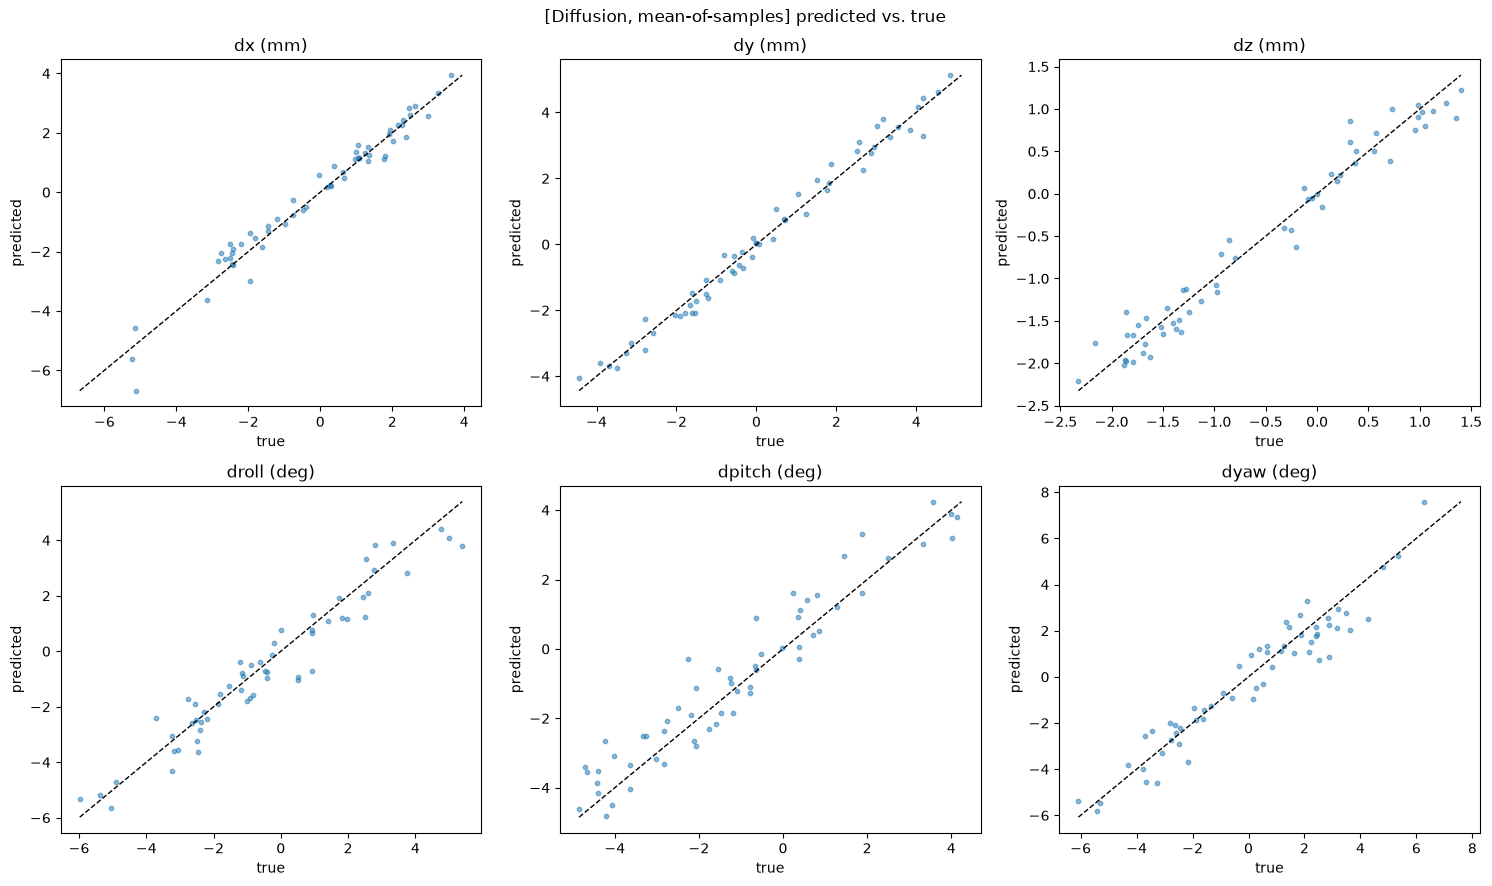

  MAE dx (mm): 0.315
  MAE dy (mm): 0.270
  MAE dz (mm): 0.172
  MAE droll (deg): 0.573
  MAE dpitch (deg): 0.609
  MAE dyaw (deg): 0.658

Mean predictive std (uncertainty) per dim, in the same units as MAE above:
  dx (mm): 0.483
  dy (mm): 0.502
  dz (mm): 0.264
  droll (deg): 0.802
  dpitch (deg): 0.848
  dyaw (deg): 0.866


In [21]:
@torch.no_grad()
def collect_diffusion_predictions(model, schedule, loader, device, target_mean, target_std, num_samples):
    all_mean_preds, all_stds, all_targets = [], [], []
    for images, targets in loader:
        samples = diffusion_sample(model, schedule, images, device, num_samples)  # (B, S, 6)
        all_mean_preds.append(samples.mean(dim=1).cpu())
        all_stds.append(samples.std(dim=1).cpu())
        all_targets.append(targets)
    mean_preds = unnormalize(torch.cat(all_mean_preds), target_mean, target_std).numpy()
    stds_phys = (torch.cat(all_stds) * torch.as_tensor(target_std)).numpy()
    targets_phys = unnormalize(torch.cat(all_targets), target_mean, target_std).numpy()
    return mean_preds, stds_phys, targets_phys


if diffusion_model is not None:
    diff_preds_phys, diff_stds_phys, diff_targets_phys = collect_diffusion_predictions(
        diffusion_model, diffusion_schedule, val_loader, DEVICE, TARGET_MEAN, TARGET_STD, CFG["diff_eval_samples"]
    )
    plot_pred_vs_true(diff_preds_phys, diff_targets_phys, dim_names, scale,
                       title_prefix="[Diffusion, mean-of-samples]")

    print("\nMean predictive std (uncertainty) per dim, in the same units as MAE above:")
    for name, s in zip(dim_names, diff_stds_phys.mean(0) * scale):
        print(f"  {name}: {s:.3f}")
else:
    diff_preds_phys, diff_stds_phys, diff_targets_phys = None, None, None
    print("Skipping diffusion evaluation plots (diffusion_model is None).")

## 5. Regressor vs. diffusion -- summary

Same validation set, same units, so the MAE numbers above are directly
comparable. If the diffusion model's per-dim predictive std stays small
and its MAE is close to the regressor's, the residual distribution is
likely close to unimodal and the (much cheaper to run) regressor is the
better default; large std or a clear MAE edge for diffusion indicates real
multi-modality worth keeping the diffusion model for.


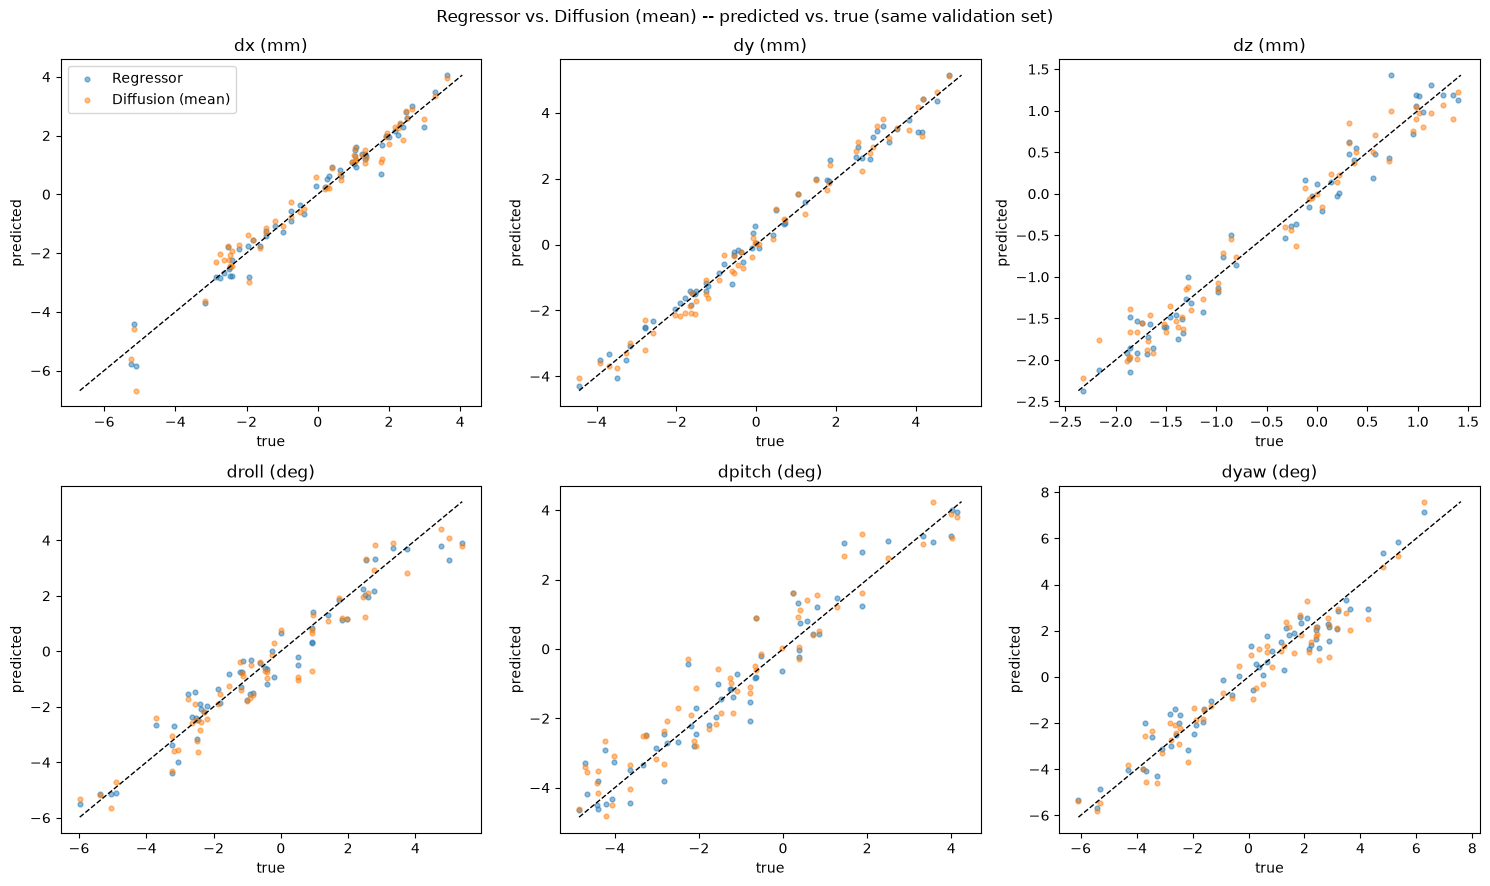

In [22]:
def plot_pred_vs_true_combined(preds_by_model, targets_phys, dim_names, scale):
    """Overlays each model's predicted-vs-true scatter (different color per
    model, same axes) so their spread/bias can be compared directly."""
    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    for i, ax in enumerate(axes.flat):
        t = targets_phys[:, i] * scale[i]
        all_vals = [t]
        for (label, preds_phys), color in zip(preds_by_model.items(), colors):
            p = preds_phys[:, i] * scale[i]
            ax.scatter(t, p, s=12, alpha=0.5, label=label, color=color)
            all_vals.append(p)
        lims = [min(v.min() for v in all_vals), max(v.max() for v in all_vals)]
        ax.plot(lims, lims, "k--", linewidth=1)
        ax.set_xlabel("true")
        ax.set_ylabel("predicted")
        ax.set_title(dim_names[i])
        if i == 0:
            ax.legend()
    fig.suptitle(" vs. ".join(preds_by_model.keys()) + " -- predicted vs. true (same validation set)")
    plt.tight_layout()
    plt.show()


# Built from whichever model(s) actually ran this session (CFG["models_to_run"]);
# reg_targets_phys and diff_targets_phys come from the same (shuffle=False)
# val_loader when both ran, so they're the same underlying samples/order --
# reused as _preds_by_model/_common_targets_phys by sections 5 and 6 below.
_preds_by_model = {}
_common_targets_phys = None
if reg_preds_phys is not None:
    _preds_by_model["Regressor"] = reg_preds_phys
    _common_targets_phys = reg_targets_phys
if diff_preds_phys is not None:
    _preds_by_model["Diffusion (mean)"] = diff_preds_phys
    _common_targets_phys = diff_targets_phys

if len(_preds_by_model) >= 2:
    plot_pred_vs_true_combined(_preds_by_model, _common_targets_phys, dim_names, scale)
elif len(_preds_by_model) == 1:
    print(f"Only {next(iter(_preds_by_model))} ran this session (CFG['models_to_run']) -- "
          "nothing to compare here; see its predicted-vs-true plot in section 3.1/4.1 above.")
else:
    print("No models were evaluated this session -- set CFG['models_to_run'] to include "
          "'regressor' and/or 'diffusion' and rerun sections 3/4.")

In [23]:
def summarize(name, preds_phys, targets_phys):
    mae = np.abs(preds_phys - targets_phys).mean(0) * scale
    rmse = np.sqrt(((preds_phys - targets_phys) ** 2).mean(0)) * scale
    print(f"{name:>12s} | " + "  ".join(f"{n}: MAE={m:.3f} RMSE={r:.3f}" for n, m, r in zip(dim_names, mae, rmse)))


for _name, _preds in _preds_by_model.items():
    summarize(_name, _preds, _common_targets_phys)

print(f"\nCheckpoints saved to: {CFG['ckpt_dir']}/")
print(f"TensorBoard logs in: {CFG['log_dir']}/  (tensorboard --logdir {CFG['log_dir']})")

   Regressor | dx (mm): MAE=0.262 RMSE=0.356  dy (mm): MAE=0.250 RMSE=0.311  dz (mm): MAE=0.174 RMSE=0.214  droll (deg): MAE=0.531 RMSE=0.647  dpitch (deg): MAE=0.517 RMSE=0.678  dyaw (deg): MAE=0.601 RMSE=0.717
Diffusion (mean) | dx (mm): MAE=0.315 RMSE=0.424  dy (mm): MAE=0.270 RMSE=0.330  dz (mm): MAE=0.172 RMSE=0.209  droll (deg): MAE=0.573 RMSE=0.709  dpitch (deg): MAE=0.609 RMSE=0.740  dyaw (deg): MAE=0.658 RMSE=0.820

Checkpoints saved to: /home/intrinsic/ws_aic/src/aic/aic_solution/dataset/checkpoints/
TensorBoard logs in: /home/intrinsic/ws_aic/src/aic/aic_solution/dataset/runs/  (tensorboard --logdir /home/intrinsic/ws_aic/src/aic/aic_solution/dataset/runs)
